In [1]:
#Connecting to google drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Your path

VIDEO_PATH = "/content/drive/MyDrive/video_data/test/v_ShavingBeard_g03_c01.avi"

In [3]:
# Displaying the video for quick viewing. avi can't be displayed, so converting to mp4.

import os
from IPython.display import HTML
from base64 import b64encode

# Convert AVI to MP4 for browser playback
os.system(f"ffmpeg -i {VIDEO_PATH} -vcodec libx264 -acodec aac -y output.mp4")

# Display the result
mp4 = open('output.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=400 controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")

In [4]:
# Displaying the time, height, width, channels in OpenCV order - THWC

import cv2

cap = cv2.VideoCapture(VIDEO_PATH)

if cap.isOpened():
    # Get the standard properties
    T = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # Time (Total Frames)
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) # Height
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))  # Width
    C = 3                                       # Channels (BGR is standard)

    print(f"Standard OpenCV Order (T, H, W, C): ({T}, {H}, {W}, {C})")
else:
    print("Could not open video. Check your path!")

cap.release()

Standard OpenCV Order (T, H, W, C): (98, 240, 320, 3)


In [5]:
!pip install av

In [6]:
# Dimensions of video in torch - TCHW

import torch
import torchvision
from torchvision.io import read_video

# Load the video
# pts_unit='sec' is the standard for modern torchvision reading
vframes, aframes, info = read_video(VIDEO_PATH, pts_unit='sec', output_format='TCHW')

print(f"Original shape (T, C, H, W): {vframes.shape}")
print(f"Total frames in video: {vframes.shape[0]}")

Original shape (T, C, H, W): torch.Size([98, 3, 240, 320])
Total frames in video: 98


/usr/local/lib/python3.12/dist-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


In [7]:
# Uniform Temporal Sampling: Most models require a fixed number of frames (e.g., 16). Since videos have different lengths, we use torch.linspace to pick 16 frames evenly distributed from start to finish.

num_frames = 16
t = vframes.shape[0]

# Generate 16 indices ranging from 0 to (total frames - 1)
indices = torch.linspace(0, t - 1, num_frames).long()
print(f"Indices selected: {indices}")

# Select only those frames
vframes_sampled = vframes[indices]

print(f"Sampled shape (T, C, H, W): {vframes_sampled.shape}")

Indices selected: tensor([ 0,  6, 12, 19, 25, 32, 38, 45, 51, 58, 64, 71, 77, 84, 90, 97])
Sampled shape (T, C, H, W): torch.Size([16, 3, 240, 320])


In [8]:
# Dimension Permutation: Video models like Swin3D or I3D usually expect the dimensions in - CTHW

# permute(1, 0, 2, 3) moves:
# Index 1 (C) -> Position 0
# Index 0 (T) -> Position 1
# Index 2 (H) -> Position 2
# Index 3 (W) -> Position 3

vframes_permuted = vframes_sampled.permute(1, 0, 2, 3)

print(f"Final shape for Model (C, T, H, W): {vframes_permuted.shape}")

Final shape for Model (C, T, H, W): torch.Size([3, 16, 240, 320])


In [9]:
# Normalization and Resizing: We scale the pixel values. The read_video function returns uint8 (0-255). Neural networks prefer floats (0-1).

# Convert to float and scale
vframes_final = vframes_permuted.float() / 255.0

print(f"Max pixel value: {vframes_final.max()}")
print(f"Min pixel value: {vframes_final.min()}")

Max pixel value: 1.0
Min pixel value: 0.0


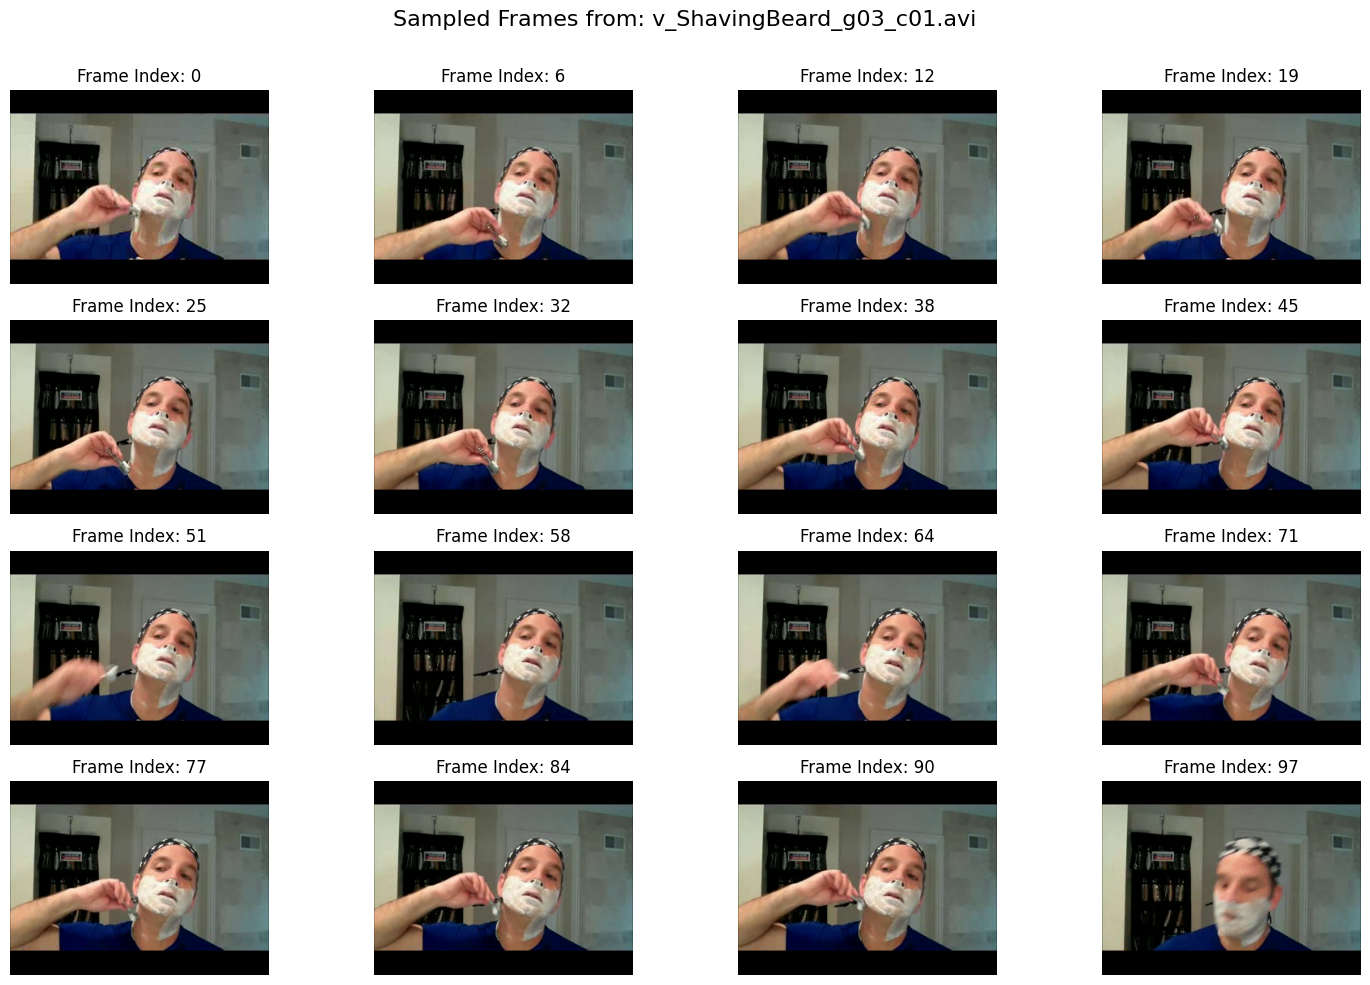

In [10]:
# Visualizing the Sampled Frames

import matplotlib.pyplot as plt
import numpy as np

# 1. Take our sampled tensor: vframes_sampled (T, C, H, W)
# 2. We need to permute it to (T, H, W, C) for Matplotlib
vis_frames = vframes_sampled.permute(0, 2, 3, 1)

# 3. Create the figure
fig, axes = plt.subplots(4, 4, figsize=(15, 10))
fig.suptitle(f"Sampled Frames from: {os.path.basename(VIDEO_PATH)}", fontsize=16)

for i, ax in enumerate(axes.flat):
    if i < len(vis_frames):
        # Convert tensor to numpy and ensure it's uint8 for plotting
        img = vis_frames[i].numpy().astype(np.uint8)

        ax.imshow(img)
        ax.set_title(f"Frame Index: {indices[i].item()}")
        ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [13]:
# Resizing for Swin3D model input

from torchvision import transforms

# 1. Define the transform pipeline
# Swin3D typically expects 224x224
transform_pipeline = transforms.Compose([
    transforms.Resize(224),         # Resizes the smaller edge to 224
    transforms.CenterCrop(224),     # Crops a 224x224 square from the center
])

# 2. Apply to our permuted tensor (C, T, H, W)
# We cast to float first because transforms work best with float tensors
vframes_transformed = transform_pipeline(vframes_permuted.float() / 255.0)

print(f"Pre-transform shape: {vframes_permuted.shape}")
print(f"Post-transform shape: {vframes_transformed.shape}")

Pre-transform shape: torch.Size([3, 16, 240, 320])
Post-transform shape: torch.Size([3, 16, 224, 224])


In [14]:
# Adding the Batch Dimension: Deep learning models don't process one video at a time, they process batches. Even if you only have one video, the model expects a 5D tensor: (Batch, Channels, Time, Height, Width)

# unsqueeze(0) adds a dimension at index 0
input_tensor = vframes_transformed.unsqueeze(0)

print(f"Final Tensor Shape for Model: {input_tensor.shape}")
# Result should be: torch.Size([1, 3, 16, 224, 224])

Final Tensor Shape for Model: torch.Size([1, 3, 16, 224, 224])


Now we’re moving into the "Brain" of the operation. To see if our preprocessing worked, we’ll load the Swin3D-Tiny model. This model was trained on the Kinetics-400 dataset, which contains 400 different human actions (like "shaving beard").

In [15]:
from torchvision.models.video import swin3d_t, Swin3D_T_Weights

# 1. Initialize model with pre-trained weights
weights = Swin3D_T_Weights.KINETICS400_V1
model = swin3d_t(weights=weights)

# 2. Set to evaluation mode (important for Dropout/Batchnorm layers)
model.eval()

# 3. Get the list of action categories
categories = weights.meta["categories"]
print(f"Model loaded! It can recognize {len(categories)} different actions.")

Downloading: "https://download.pytorch.org/models/swin3d_t-7615ae03.pth" to /root/.cache/torch/hub/checkpoints/swin3d_t-7615ae03.pth


100%|██████████| 122M/122M [00:02<00:00, 60.0MB/s]


Model loaded! It can recognize 400 different actions.


Now we pass our input_tensor (the  1×3×16×224×224  tensor we made) through the model

In [16]:
with torch.no_grad():
    # Push the video through the model
    logits = model(input_tensor)

    # Convert output to probabilities
    probabilities = torch.nn.functional.softmax(logits[0], dim=0)

# Get the top 5 predictions
top5_prob, top5_catid = torch.topk(probabilities, 5)

print(f"--- Top Predictions for your video ---")
for i in range(top5_prob.size(0)):
    print(f"{categories[top5_catid[i]]}: {top5_prob[i].item()*100:.2f}%")

--- Top Predictions for your video ---
trimming or shaving beard: 99.21%
brush painting: 0.61%
brushing teeth: 0.07%
applying cream: 0.02%
getting a haircut: 0.02%
